# 3B - Alvo, eventos e ciclo de vida (NOAA/ONI local)

**Pergunta especifica.** Como os eventos El Nino locais, definidos pela regra NOAA/ONI compativel, nascem, crescem, picam e decaem nas classes `fraco`, `moderado`, `forte` e `muito_forte`?

**Objetivo.** Caracterizar duracao, crescimento, decaimento, persistencia e trajetorias compostas usando a media movel de 3 meses da SSTA Nino 3.4 e os limiares NOAA de intensidade.

**Justificativa.** A Fase 3 adota a definicao NOAA/ONI local. O evento exige SSTA Nino 3.4 >=+0.5 C em 5 estacoes moveis de 3 meses, e a intensidade vem do pico dessa media movel: fraco, moderado, forte ou muito forte.

**Metodologia.** Eventos = media movel de 3 meses da SSTA Nino 3.4 >=+0.5 C por 5+ estacoes sobrepostas na base OISST local. Classes NOAA: fraco [0.5,1.0), moderado [1.0,1.5), forte [1.5,2.0), muito_forte >=2.0 C. Trajetorias alinhadas ao pico; autocorrelacao semanal 1-78 lags; mapa composto dos eventos `muito_forte`.

**Saidas.** `phase3B_eventos_taxas.csv`, `phase3B_trajetorias_compostas.csv`, `phase3B_grupos_classes_noaa.csv`, `phase3B_memoria_persistencia.csv`, `phase3B_mapa_composto_resumo.csv` + figuras.


In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, xarray as xr
import fase3_utils as u
weekly=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev=u.events_noaa().copy()
ssta=weekly['nino34_ssta']
rows=[]
for _,e in ev.iterrows():
    don=(e.peak_time-e.event_start).days/30.44; doff=(e.event_end-e.peak_time).days/30.44
    s0,sp,s1=ssta.asof(e.event_start),ssta.asof(e.peak_time),ssta.asof(e.event_end)
    rows.append({'event_id':e.event_id,'classe':e.classe_noaa,'oni_pico_c':round(e.peak_oni_local_c if 'peak_oni_local_c' in e else e.peak_ssta_c,3),'ssta_mensal_pico_c':round(e.peak_monthly_ssta_c,3),'duracao_estacoes_oni':e.duration_oni_seasons if 'duration_oni_seasons' in e else e.duration_months,
     'crescimento_c_por_mes':round((sp-s0)/max(don,1e-9),3),'decaimento_c_por_mes':round((s1-sp)/max(doff,1e-9),3),
     'limiar_evento_oni_c':0.5,'criterio_temporal':'5+ estacoes moveis de 3 meses'})
taxas=pd.DataFrame(rows); u.save_table(taxas,'phase3B_eventos_taxas.csv',index=False)
print('eventos elegiveis NOAA/ONI local =',len(ev)); taxas


[tabela] data\processed\parquet\statistics\phase3B_eventos_taxas.csv
eventos elegiveis NOAA/ONI local = 12


,event_id,classe,oni_pico_c,ssta_mensal_pico_c,duracao_estacoes_oni,crescimento_c_por_mes,decaimento_c_por_mes,limiar_evento_oni_c,criterio_temporal
0,el_nino_oisst_1982_1983,muito_forte,2.120,2.213,11,0.306,-0.470,0.5,5+ estacoes moveis de 3 meses
1,el_nino_oisst_1986_1988,moderado,1.211,1.223,16,0.048,-0.048,0.5,5+ estacoes moveis de 3 meses
2,el_nino_oisst_1991_1992,forte,1.625,1.736,10,0.325,-0.167,0.5,5+ estacoes moveis de 3 meses
3,el_nino_oisst_1994_1995,fraco,0.968,1.192,5,0.428,-0.251,0.5,5+ estacoes moveis de 3 meses
4,el_nino_oisst_1997_1998,muito_forte,2.146,2.166,11,0.241,-0.249,0.5,5+ estacoes moveis de 3 meses
5,el_nino_oisst_2002_2003,moderado,1.213,1.250,8,0.173,-0.148,0.5,5+ estacoes moveis de 3 meses
6,el_nino_oisst_2004,fraco,0.652,0.681,5,-0.051,-0.037,0.5,5+ estacoes moveis de 3 meses
7,el_nino_oisst_2006_2007,fraco,0.920,1.128,5,0.164,0.204,0.5,5+ estacoes moveis de 3 meses
8,el_nino_oisst_2009_2010,forte,1.586,1.719,10,0.172,-0.149,0.5,5+ estacoes moveis de 3 meses
9,el_nino_oisst_2014_2016,muito_forte,2.592,2.448,19,0.188,-0.382,0.5,5+ estacoes moveis de 3 meses


[tabela] data\processed\parquet\statistics\phase3B_trajetorias_compostas.csv
[tabela] data\processed\parquet\statistics\phase3B_grupos_classes_noaa.csv


[figura] data\processed\figures\fase3\3B1_trajetorias_compostas.png


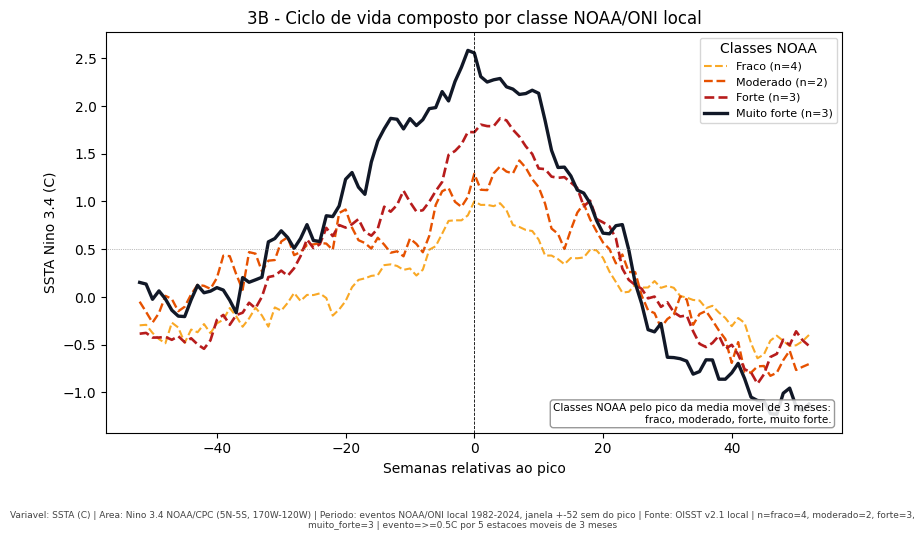

In [2]:
lags=list(range(-52,53))
groups=u.elnino_mean_groups(ev)

def peak_aligned(series,e):
    i=series.index.get_indexer([e.peak_time],method='nearest')[0]
    seg=series.iloc[max(0,i-52):i+53]
    rel=((seg.index-series.index[i]).days/7).round().astype(int)
    return pd.Series(seg.values,index=rel).reindex(lags)

comp={}
for grupo,gg in groups.items():
    frames=[peak_aligned(ssta,e) for _,e in gg.iterrows()]
    comp[grupo]=pd.DataFrame(frames).mean() if frames else pd.Series(index=lags,dtype=float)
comp=pd.DataFrame({g:comp[g] for g in u.ELNINO_MEAN_GROUP_ORDER})
u.save_table(comp.rename_axis('semana_rel_pico'),'phase3B_trajetorias_compostas.csv')
u.save_table(u.elnino_mean_group_table()[['grupo','rotulo','definicao']],'phase3B_grupos_classes_noaa.csv',index=False)
fig,ax=plt.subplots(figsize=(9.5,5.2))
for grupo in u.ELNINO_MEAN_GROUP_ORDER:
    if len(groups[grupo]) == 0: continue
    meta=u.elnino_group_style(grupo)
    label=f"{meta['rotulo_curto']} (n={len(groups[grupo])})"
    ax.plot(comp.index,comp[grupo],label=label,color=meta['color'],lw=meta['linewidth'],ls=meta['linestyle'])
ax.axvline(0,color='k',ls='--',lw=.6); ax.axhline(.5,color='grey',ls=':',lw=.5); ax.legend(fontsize=8,title='Classes NOAA')
ax.set_xlabel('Semanas relativas ao pico'); ax.set_ylabel('SSTA Nino 3.4 (C)'); ax.set_title('3B - Ciclo de vida composto por classe NOAA/ONI local')
u.add_note(ax, 'Classes NOAA pelo pico da media movel de 3 meses:\nfraco, moderado, forte, muito forte.', loc='lower right')
counts=ev['classe_noaa'].value_counts().to_dict()
u.stamp_caption(fig,variavel='SSTA (C)',area=u.CAIXAS['nino34'],periodo='eventos NOAA/ONI local 1982-2024, janela +-52 sem do pico',
 fonte='OISST v2.1 local',n=', '.join(f"{k}={counts.get(k,0)}" for k in u.ELNINO_MEAN_GROUP_ORDER),extra='evento=>=0.5C por 5 estacoes moveis de 3 meses')
u.save_fig(fig,'3B1_trajetorias_compostas.png'); plt.show()


[tabela] data\processed\parquet\statistics\phase3B_autocorrelacao.csv


[figura] data\processed\figures\fase3\3B2_autocorrelacao.png


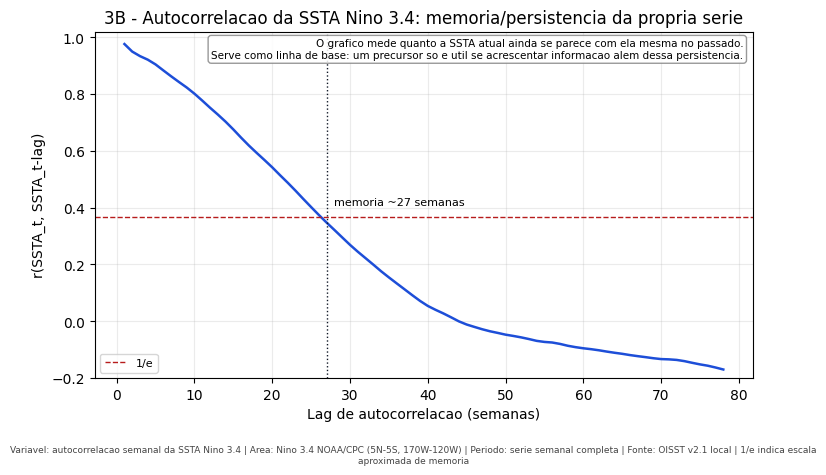

Escala de memoria 1/e: 27 semanas


In [3]:
ac = pd.Series({lag: ssta.autocorr(lag) for lag in range(1, 79)}, name='autocorrelacao')
below = ac[ac < 1/np.e]
efold = int(below.index.min()) if len(below) else np.nan
mem = ac.to_frame()
mem['abaixo_1_sobre_e'] = ac < 1/np.e
mem['interpretacao'] = 'memoria da SSTA ainda relevante'
mem.loc[mem['abaixo_1_sobre_e'], 'interpretacao'] = 'memoria caiu abaixo de 1/e'
u.save_table(mem, 'phase3B_autocorrelacao.csv')
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(ac.index, ac.values, color='#1d4ed8', lw=1.8)
ax.axhline(1/np.e, ls='--', color='#b71c1c', lw=1, label='1/e')
if np.isfinite(efold):
    ax.axvline(efold, ls=':', color='#111827', lw=1)
    ax.text(efold+1, 1/np.e+0.04, f'memoria ~{efold} semanas', fontsize=8)
ax.set_xlabel('Lag de autocorrelacao (semanas)')
ax.set_ylabel('r(SSTA_t, SSTA_t-lag)')
ax.set_ylim(-0.2, 1.02)
ax.set_title('3B - Autocorrelacao da SSTA Nino 3.4: memoria/persistencia da propria serie')
ax.grid(alpha=.25)
ax.legend(fontsize=8)
u.add_note(ax, 'O grafico mede quanto a SSTA atual ainda se parece com ela mesma no passado.\nServe como linha de base: um precursor so e util se acrescentar informacao alem dessa persistencia.', loc='upper right')
u.stamp_caption(fig, variavel='autocorrelacao semanal da SSTA Nino 3.4', area=u.CAIXAS['nino34'], periodo='serie semanal completa', fonte='OISST v2.1 local', extra='1/e indica escala aproximada de memoria')
u.save_fig(fig, '3B2_autocorrelacao.png')
plt.show()
print('Escala de memoria 1/e:', efold, 'semanas')


[tabela] data\processed\parquet\statistics\phase3B_mapa_composto_resumo.csv


[figura] data\processed\figures\fase3\3B3_mapa_composto_pico.png


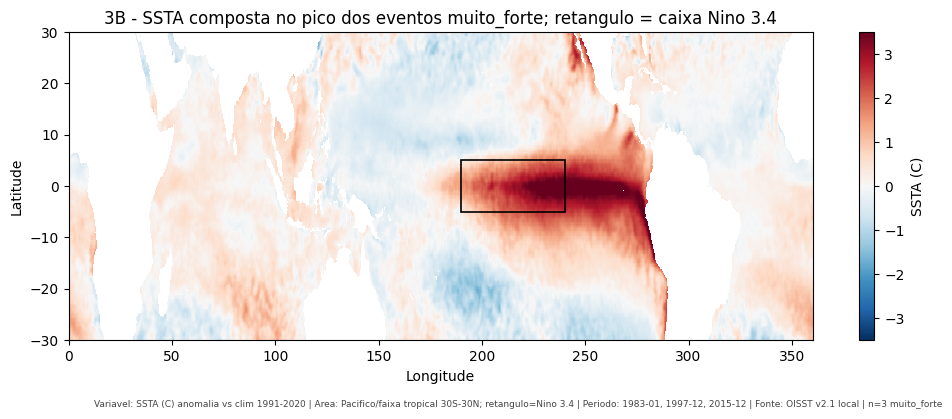

,evento,ssta_max_c,ssta_media_nino34_c
0,1983-01,5.341,2.227
1,1997-12,6.091,2.181
2,2015-12,4.284,2.461


In [4]:
MAPC=u.ROOT/'data/interim/fase3_map_cache'
def mf(y,m):
    f=MAPC/f'sst_month_{y}_{m:02d}.nc'
    if f.exists(): return xr.open_dataarray(f)
    try: ds=xr.open_zarr(u.ROOT/f'data/processed/zarr/cpc_noaa/oisst/sst.day.mean.{y}.zarr',consolidated=False)
    except Exception: ds=xr.open_dataset(u.ROOT/f'data/raw/cpc_noaa/oisst/sst.day.mean.{y}.nc')
    fld=ds['sst'].sel(time=f'{y}-{m:02d}').mean('time').sel(lat=slice(-30,30)).load(); ds.close(); return fld
super_ev=ev.query("classe_noaa == 'muito_forte'").copy()
fields=[]
for _,e in super_ev.iterrows():
    y=int(e.peak_time.year); m=int(e.peak_time.month)
    clim=xr.concat([mf(cy,m) for cy in range(1991,2021)],'y').mean('y')
    fields.append((f'{y}-{m:02d}',(mf(y,m)-clim).load()))
cf=xr.concat([f for _,f in fields],'e').mean('e')
fig,ax=plt.subplots(figsize=(12,4)); pc=ax.pcolormesh(cf.lon,cf.lat,cf.values,cmap='RdBu_r',vmin=-3.5,vmax=3.5,shading='auto')
ax.add_patch(plt.Rectangle((190,-5),50,10,fill=False,ec='k',lw=1.2)); ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('3B - SSTA composta no pico dos eventos muito_forte; retangulo = caixa Nino 3.4')
fig.colorbar(pc,ax=ax,label='SSTA (C)')
u.stamp_caption(fig,variavel='SSTA (C) anomalia vs clim 1991-2020',area='Pacifico/faixa tropical 30S-30N; retangulo=Nino 3.4',
 periodo=', '.join(pk for pk,_ in fields),fonte='OISST v2.1 local',n=f'{len(fields)} muito_forte')
res=pd.DataFrame([{'evento':pk,'ssta_max_c':round(float(f.max()),3),'ssta_media_nino34_c':round(float(f.sel(lat=slice(-5,5),lon=slice(190,240)).mean()),3)} for pk,f in fields])
u.save_table(res,'phase3B_mapa_composto_resumo.csv',index=False); u.save_fig(fig,'3B3_mapa_composto_pico.png'); plt.show(); res


**Leitura do 3B.** A Fase 3 passa a usar a classificacao NOAA/ONI local: `fraco`, `moderado`, `forte` e `muito_forte`, baseada no pico da media movel de 3 meses da SSTA Nino 3.4. O evento termico exige >=+0.5 C por 5 estacoes moveis sobrepostas. A persistencia da SSTA continua em escala semestral (e-folding ~27 semanas), que e o baseline que a Fase 5 tera de superar. O mapa composto `muito_forte` confirma que a caixa Nino 3.4 captura o nucleo do aquecimento extremo.
